In [350]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import os
from random import shuffle

In [351]:

def get_data(directory, dirs):

    max_jerks = []
    max_accs = []
    max_vels = []
    max_heights = []

    jerks = []
    accelerations = []
    velocities = []
    heights = []
    timestamps = []

    for filename in dirs:
        if filename.endswith('.csv'):
            file_path = os.path.join(directory, filename)
            
            df = pd.read_csv(file_path)
            
            max_jerk = df['aJerk'].abs().max()
            max_vel = df['aVelocity'].abs().max()
            max_acc = df['aAcc'].abs().max()
            max_height = df['aHeight'].max()

            max_jerks.extend([max_jerk for i in range(len(df))])
            max_accs.extend([max_acc for i in range(len(df))])
            max_vels.extend([max_vel for i in range(len(df))])
            max_heights.extend([max_height for i in range(len(df))])

            jerks.extend(df['aJerk'].abs())
            accelerations.extend(df['aAcc'].abs())
            velocities.extend(df['aVelocity'].abs())
            heights.extend(df['aHeight'].abs())
            timestamps.extend(df['timestamps'])

    data = {
        "max_jerk": max_jerks,
        "max_acc": max_accs,
        "max_vel": max_vels,
        "max_height": max_heights,
        "jerks": jerks,
        "accelerations": accelerations,
        "velocities": velocities,
        "heights": heights,
        "timestamps": timestamps
        }   

    return pd.DataFrame(data)


In [352]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import KFold, cross_val_score


directory = './lr_data'
# Degree 4 with power 1 gives 86.5%
# Thats the highest I can get, appear to overfit drastically after any increase
# The range is massive tho, 86.5% was the highest I could get
degree = 5
power = 1/3
dirs = os.listdir(directory)
shuffle(dirs)
test_size = 15
training_df = get_data(directory, dirs[:-test_size])
test_df = get_data(directory, dirs[-test_size:])

import warnings
warnings.filterwarnings("ignore")

predicting = 'accelerations'
for degree in range(3, 9):
    for power in [1, 1/2, 1/3, 1/6]:
        print("***MODEL****")
        print(f"DEGREE: {degree}")
        print(f"POWER: {power}")
        # Define the polynomial model with Ridge regression
        poly_model = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=0.85))

        # Prepare training features and target variable
        training_features = training_df[['timestamps', 'max_jerk', 'max_acc', 'max_vel', 'max_height']]
        training_features = training_features.apply(lambda x: np.power(x, power))

        # Apply RFE with the specified number of features
        # poly_model = RFE(poly_model, n_features_to_select=3)

        # Define the cross-validation strategy: 5-Fold Cross-Validation
        kf = KFold(n_splits=5, shuffle=True, random_state=42)

        # Perform cross-validation with RFE
        cv_scores = cross_val_score(poly_model, training_features, training_df[predicting], cv=kf, scoring='neg_mean_squared_error')

        # Convert the negative MSE scores to positive and calculate RMSE
        mse_scores = -cv_scores
        rmse_scores = np.sqrt(mse_scores)

        print("Cross-validated MSE scores: ", mse_scores)
        print("Cross-validated RMSE scores: ", rmse_scores)
        print("Average RMSE: ", rmse_scores.mean())

        # After cross-validation, fit the model on the entire training data
        poly_model.fit(training_features, training_df[predicting])

        # Prepare test features and make predictions
        test_features = test_df[['timestamps', 'max_jerk', 'max_acc', 'max_vel', 'max_height']]
        test_features = test_features.apply(lambda x: np.power(x, power))
        test_df[f'predicted_{predicting}'] = poly_model.predict(test_features)

        # Evaluate the model on the test set
        print(f"Test set R^2 score: {poly_model.score(test_features, test_df[predicting])}")


ImportError: cannot import name 'LinAlgWarning' from 'numpy.linalg' (c:\Users\Oliver Greenwood\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\linalg\__init__.py)

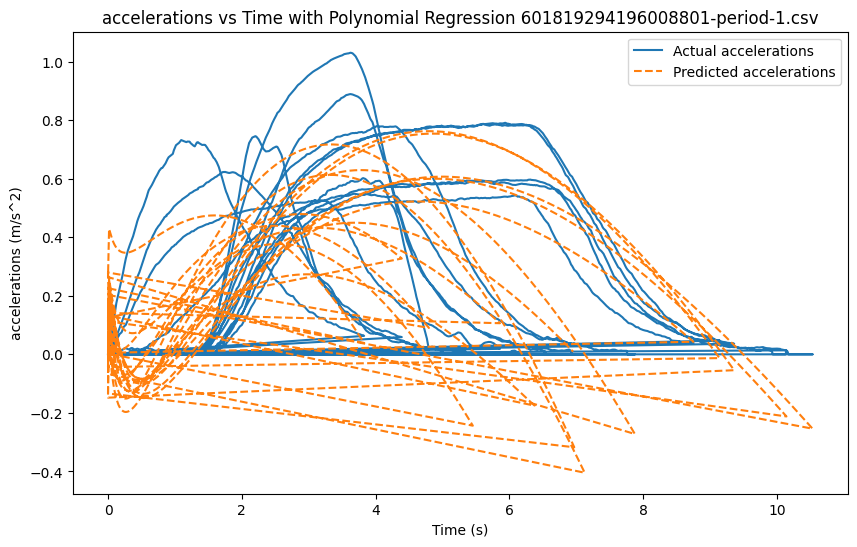

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(test_df['timestamps'], test_df[predicting], label=f'Actual {predicting}')
plt.plot(test_df['timestamps'], test_df[f'predicted_{predicting}'], label=f'Predicted {predicting}', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel(f'{predicting} (m/s^2)')
plt.legend()
plt.title(f'{predicting} vs Time with Polynomial Regression {dirs[-1]}')
plt.show()

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import os
from random import choice

In [ ]:

def get_periods(result_file, buffer):
    with open("./results/" + result_file, "r") as f:
        df = pd.read_csv(f)

    period_dfs = []
    i = 0
    # collect_at_two = True
    previous_end = 0
    while i < len(df):

        period = []
        
        # Collect data until aStages is non-zero and there's at least one period element
        while i < len(df) and (df['aStages'].iloc[i] in [1, 3] or not len(period)):
            if df['aStages'].iloc[i] in [1, 3]:
                period.append([
                    df['timestamps'].iloc[i],
                    df['aAcc'].iloc[i],
                    df['aJerk'].iloc[i],
                    df['aVelocity'].iloc[i],
                    df['aHeight'].iloc[i]
                ])
            i += 1
        # twos = 0
        # while i < len(df) and (df['aStages'].iloc[i] != 0 or not period):

        #     if df['aStages'].iloc[i] != 0:
        #         period.append([
        #             df['timestamps'].iloc[i],
        #             df['aAcc'].iloc[i],
        #             df['aJerk'].iloc[i],
        #             df['aVelocity'].iloc[i],
        #             df['aHeight'].iloc[i]
        #         ])
            
        #     if collect_at_two and df['aStages'].iloc[i] == 2:
        #         twos += 1

        #     elif df['aStages'].iloc[i] == 3 and twos > 0:
                
        #         i -= int(twos / 2)
        #         period = period[:-int(twos / 2)]
        #         collect_at_two = False
        #         break

        #     i += 1

        # else:
        #     collect_at_two = True


        if not len(period) or i >= len(df): continue

        for j in range(max(0, i - len(period) - 1), max(i - len(period) - buffer, previous_end) - 1, -1):
            period.insert(0, [
                    df['timestamps'].iloc[j],
                    df['aAcc'].iloc[j],
                    df['aJerk'].iloc[j],
                    df['aVelocity'].iloc[j],
                    df['aHeight'].iloc[j]
                ])

        sliced_df = df.iloc[i + 1:]
        next_stage = sliced_df[sliced_df['aStages'].apply(lambda x: x in [1, 3])].index
        next_stage = len(df) - 1 if len(next_stage) == 0 else next_stage[0]

        for i in range(i, min(int((next_stage - i) / 2 + i), i + buffer)):
            period.append([
                    df['timestamps'].iloc[i],
                    df['aAcc'].iloc[i],
                    df['aJerk'].iloc[i],
                    df['aVelocity'].iloc[i],
                    df['aHeight'].iloc[i]
                ])

        previous_end = i

        period_df = pd.DataFrame(period, columns=['timestamps', 'aAcc', 'aJerk', 'aVelocity', 'aHeight'])

        period_df["jerks_direction"] = "up" if period_df['aJerk'].iloc[len(period_df) - 1] - period_df['aJerk'].iloc[0] > 0 else "down"
        period_df["accelerations_direction"] = "up" if period_df['aAcc'].iloc[len(period_df) - 1] - period_df['aAcc'].iloc[0] > 0 else "down"
        period_df["velocities_direction"] = "up" if period_df['aVelocity'].iloc[len(period_df) - 1] - period_df['aVelocity'].iloc[0] > 0 else "down"
        period_df["heights_direction"] = "up" if period_df['aHeight'].iloc[len(period_df) - 1] - period_df['aHeight'].iloc[0] > 0 else "down"

        period_df["start_jerks"] = period_df['aJerk'].iloc[0]
        period_df["start_accelerations"] = period_df['aAcc'].iloc[0]
        period_df["start_velocities"] = period_df['aVelocity'].iloc[0]
        period_df["start_heights"] = period_df['aHeight'].iloc[0]

        period_df['actual_timestamps'] = period_df['timestamps']
        period_df['timestamps'] = period_df['timestamps'] - period_df['timestamps'].iloc[0]

        period_df['aJerk'] = period_df['aJerk'] - period_df['aJerk'].iloc[0]
        period_df['aJerk'] = abs(period_df['aJerk'])
        period_df['aJerk'] = np.where(period_df['aJerk'] < 0.01, 0, period_df['aJerk'])

        period_df['aAcc'] = period_df['aAcc'] - period_df['aAcc'].iloc[0]
        period_df['aAcc'] = abs(period_df['aAcc'])
        period_df['aAcc'] = np.where(period_df['aAcc'] < 0.01, 0, period_df['aAcc'])

        period_df['aVelocity'] = period_df['aVelocity'] - period_df['aVelocity'].iloc[0]
        period_df['aVelocity'] = abs(period_df['aVelocity'])
        period_df['aVelocity'] = np.where(period_df['aVelocity'] < 0.01, 0, period_df['aVelocity'])

        period_df['aHeight'] = period_df['aHeight'] - period_df['aHeight'].iloc[0]
        period_df['aHeight'] = abs(period_df['aHeight'])
        period_df['aHeight'] = np.where(period_df['aHeight'] < 0.01, 0, period_df['aHeight'])
        
        period_dfs.append(period_df)

    return period_dfs


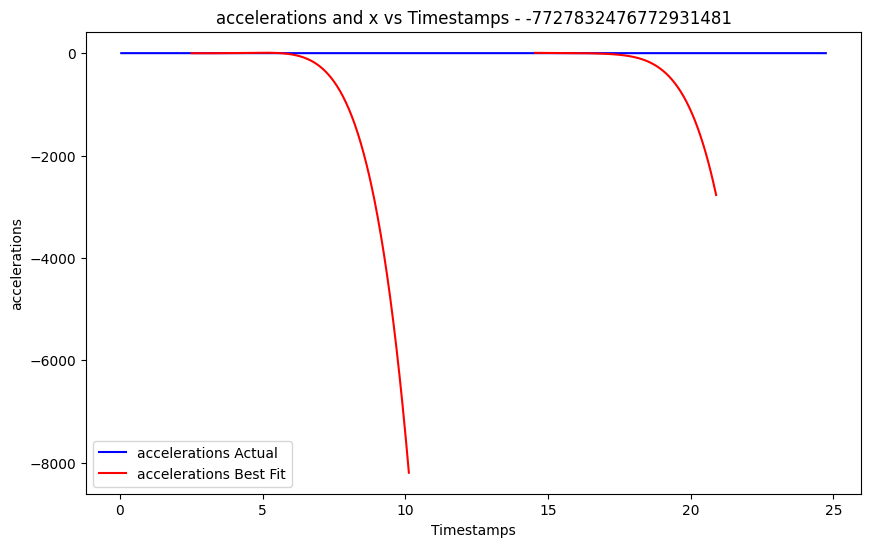

In [ ]:

# have predicitng variable
var_map = {
    "heights": "aHeight",
    "accelerations": "aAcc",
    "velocities": "aVelocity",
    "jerks": "aJerk"
}
csv_header = var_map[predicting]

# result_file = "-1729228464322526488"
result_file = choice(os.listdir("./results"))

df = pd.read_csv(os.path.join("./results/", result_file))
df['best_fit'] = None

period_dfs = get_periods(result_file, 100)
cumulative_vel = 0
for period_df in period_dfs:
    period_df['max_jerk'] = period_df['aJerk'].abs().max()
    period_df['max_vel'] = period_df['aVelocity'].abs().max()
    period_df['max_acc'] = period_df['aAcc'].abs().max()
    period_df['max_height'] = period_df['aHeight'].abs().max()
    draw_features = period_df[['timestamps', 'max_jerk', 'max_acc', 'max_vel', 'max_height']]
    period_df['predicted'] = poly_model.predict(draw_features)
    
    if period_df[f'{predicting}_direction'].iloc[0] == "down":
        period_df['predicted'] *= -1

    period_df['predicted'] = period_df['predicted'] + period_df[f'start_{predicting}'].iloc[0]

    for index, timestamp in enumerate(period_df['actual_timestamps']):
        indecies = df.index[df['timestamps'] == timestamp].tolist()
        df.at[indecies[0], 'best_fit'] = period_df['predicted'].iloc[index]


# period_df_index = 0
# inner_period_df_index = 0
# index = 0
# translation_base = 0
# while index < len(df) and period_df_index < len(period_dfs):
#     if df['aStages'].iloc[index] in [0, 2]:
#         if best_fit: best_fit.append(best_fit[-1])
#         else: best_fit = [0]
#         translation_base = best_fit[-1]
#     else:
#         best_fit.append(period_dfs[period_df_index]['predicted'].iloc[inner_period_df_index] + translation_base)
#         inner_period_df_index += 1
#         if inner_period_df_index == len(period_dfs[period_df_index]):
#             inner_period_df_index = 0
#             period_df_index += 1
    
#     index += 1


# I have 374,400 data points



# Plot df[csv_header] and df['x'] against df['timestamps']
plt.figure(figsize=(10, 6))

plt.plot(df['timestamps'], df[csv_header], label=predicting + " Actual", color='blue')

plt.plot(df['timestamps'][:len(df['best_fit'])], df['best_fit'], label=predicting + " Best Fit", color='red')

# Adding titles and labels
plt.title(f'{predicting} and x vs Timestamps - {result_file}')
plt.xlabel('Timestamps')
plt.ylabel(predicting)

# Display the legend
plt.legend()

# Show the plot
plt.show()